# Final QCNN: Rare Anomaly Screening from Compressed Image Features

This is the notebook we plan to use for the QCNN direction.

The claim is intentionally narrow: we are testing a small quantum classifier **after** an image patch has been compressed to a few image-derived features. This is not raw-pixel medical diagnosis, and it is not a proof of quantum advantage.

A realistic version of the workflow would be:

1. Start with an image patch from inspection or medical imaging.
2. Extract a small set of texture / radiomics / shape features.
3. Encode those features into a compact quantum circuit.
4. Use the circuit as a rare-anomaly screener.

Examples where this kind of workflow is at least plausible:

- industrial inspection: wafer defects, battery electrodes, weld scans, surface cracks,
- medical imaging: rare lesion screening, abnormal tissue texture, low-prevalence pathology triage.

The useful framing is:

> QCNNs are not replacing classical imaging pipelines here. They are being tested as one compact classifier inside a hybrid pipeline, especially for rare positives where accuracy alone is a bad metric.


## 1. What Is the Hard Part?

We should present the hard part as practical, not as a theorem.

The difficult setting is rare visual anomaly screening:

- positives are rare, so a model can look accurate while missing every anomaly,
- labels are expensive, especially for real defects or rare pathologies,
- useful signals may depend on feature interactions rather than one obvious pixel,
- the cost of a missed anomaly is often higher than the cost of a false alarm.

That is why the imbalanced benchmark matters. An all-normal classifier can get high ordinary accuracy while having zero anomaly recall.

The QCNN angle is structural: local interactions, pooling-like information flow, and a small number of trainable parameters. That structure is easier to motivate than a large random variational circuit.


## 2. Imports

Fixed seeds keep the notebook reproducible enough for the presentation.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.optimizers import COBYLA
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import SamplerQNN

SEED = 8398
DATA_SEED = SEED + 506
np.random.seed(SEED)

## 3. Synthetic Dataset

This is still a synthetic dataset. The labels come from a hidden anomaly rule because we do not have real labeled inspection or medical images in this notebook.

The important cleanup is that the model is **not** given the hidden variables directly. We now do this:

```text
hidden synthetic case -> 8x8 image patch -> four simple image features -> 4-qubit QCNN
```

The four features are quadrant averages from the image patch. This is a deliberately simple stand-in for real compression methods such as radiomics, PCA, texture descriptors, or a small classical encoder.

Two versions are built from the same process:

- balanced benchmark: about 50 percent anomalies,
- imbalanced deployment setting: about 8 percent anomalies.


In [2]:
def coupled_texture_score(Z):
    """Synthetic rule used to label anomalies.

    Z is the hidden case description used only to create the toy dataset.
    The models below do not receive Z or this score.
    """
    return (
        np.sin(Z[:, 0]) * np.cos(Z[:, 1])
        + np.sin(Z[:, 2] + Z[:, 3])
        + 0.25 * np.cos(Z[:, 0] - Z[:, 2])
    )


def generate_hidden_cases(n_samples=260, anomaly_rate=0.08, seed=DATA_SEED):
    """Create hidden synthetic cases and labels."""
    rng = np.random.default_rng(seed)
    Z = rng.uniform(0.0, 2 * np.pi, size=(n_samples, 4))
    scores = coupled_texture_score(Z)
    threshold = np.quantile(scores, 1.0 - anomaly_rate)
    y = (scores >= threshold).astype(int)
    return Z, y, scores, threshold


def latents_to_texture_images(Z, size=8, seed=SEED):
    """Render hidden cases as small grayscale patches.

    The four hidden values are expressed as quadrant-level image structure,
    with a little texture and noise added so the compression is not exact.
    """
    rng = np.random.default_rng(seed)
    grid = np.linspace(0, 2 * np.pi, size)
    rr, cc = np.meshgrid(grid, grid, indexing="ij")
    half = size // 2
    quadrants = [
        (slice(0, half), slice(0, half)),
        (slice(0, half), slice(half, size)),
        (slice(half, size), slice(0, half)),
        (slice(half, size), slice(half, size)),
    ]
    images = []

    for z in Z:
        img = 0.50 + 0.035 * np.sin(rr + cc) + 0.025 * np.cos(rr - cc)
        quadrant_levels = 0.18 + 0.64 * (z / (2 * np.pi))
        for level, quad in zip(quadrant_levels, quadrants):
            img[quad] += level - 0.50
        img += rng.normal(0.0, 0.025, size=(size, size))
        images.append(np.clip(img, 0.0, 1.0))

    return np.array(images)


def compress_images_to_four_features(images):
    """Compress each 8x8 image to four quadrant-mean features.

    These are the actual inputs to the classical baselines and QCNN.
    The scaling maps image intensities into angles for RY encoding.
    """
    n, height, width = images.shape
    half_h, half_w = height // 2, width // 2
    raw_features = np.column_stack([
        images[:, :half_h, :half_w].mean(axis=(1, 2)),
        images[:, :half_h, half_w:].mean(axis=(1, 2)),
        images[:, half_h:, :half_w].mean(axis=(1, 2)),
        images[:, half_h:, half_w:].mean(axis=(1, 2)),
    ])
    return np.clip((raw_features - 0.18) / 0.64, 0.0, 1.0) * 2 * np.pi


def make_visual_anomaly_dataset(n_samples=260, anomaly_rate=0.08, seed=DATA_SEED):
    """Build one synthetic image dataset and the compressed model inputs."""
    Z, y, scores, threshold = generate_hidden_cases(n_samples, anomaly_rate, seed)
    images = latents_to_texture_images(Z, size=8, seed=seed + 17)
    X = compress_images_to_four_features(images)
    return X, y, scores, threshold, images, Z


## 4. Build Balanced and Imbalanced Datasets

Both datasets use the same image-generation and compression path. The only change is where we place the anomaly threshold.


In [3]:
N_SAMPLES = 260

balanced_data = make_visual_anomaly_dataset(
    n_samples=N_SAMPLES,
    anomaly_rate=0.50,
    seed=DATA_SEED,
)
imbalanced_data = make_visual_anomaly_dataset(
    n_samples=N_SAMPLES,
    anomaly_rate=0.08,
    seed=DATA_SEED,
)

datasets = {
    "Balanced benchmark": balanced_data,
    "Imbalanced deployment": imbalanced_data,
}

for name, (X_data, y_data, scores, threshold, images, Z_hidden) in datasets.items():
    print(name)
    print("  model input shape:", X_data.shape)
    print("  clean:", int((y_data == 0).sum()), "anomaly:", int((y_data == 1).sum()), "rate:", round(float(y_data.mean()), 3))
    print("  synthetic label threshold:", round(float(threshold), 3))


Balanced benchmark
  model input shape: (260, 4)
  clean: 130 anomaly: 130 rate: 0.5
  synthetic label threshold: -0.037
Imbalanced deployment
  model input shape: (260, 4)
  clean: 239 anomaly: 21 rate: 0.081
  synthetic label threshold: 1.152


## 5. Class Balance

This plot is mostly for explaining why the balanced and imbalanced results mean different things.


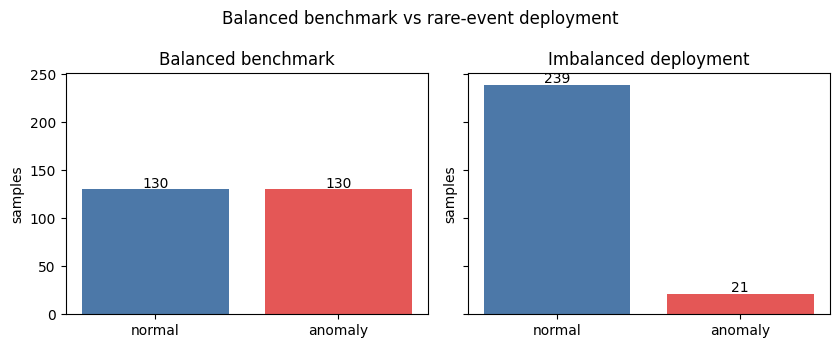

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.5), sharey=True)
for ax, (name, (_, y_data, _, _, _, _)) in zip(axes, datasets.items()):
    counts = [(y_data == 0).sum(), (y_data == 1).sum()]
    bars = ax.bar(["normal", "anomaly"], counts, color=["#4C78A8", "#E45756"])
    ax.set_title(name)
    ax.set_ylabel("samples")
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, count + 2, str(int(count)), ha="center")
fig.suptitle("Balanced benchmark vs rare-event deployment")
fig.tight_layout()
plt.show()

## 6. Example Image Patches

These are the 8x8 patches before compression. The model receives the four quadrant-mean features extracted from these images, not the hidden synthetic variables.


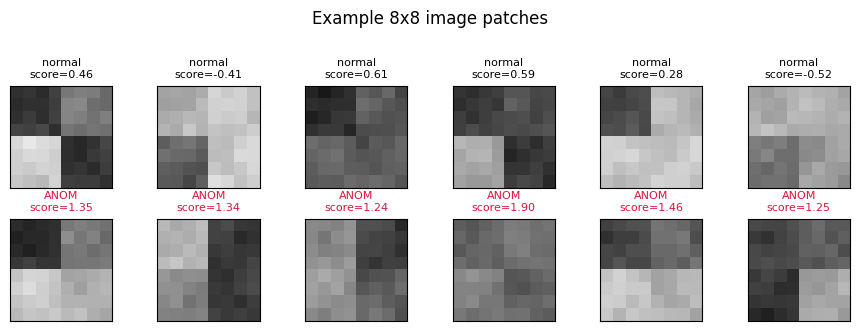

In [5]:
def show_selected_textures(images, y_data, scores, title, n_normal=6, n_anomaly=6):
    normal_idx = np.flatnonzero(y_data == 0)[:n_normal]
    anomaly_idx = np.flatnonzero(y_data == 1)[:n_anomaly]
    order = np.concatenate([normal_idx, anomaly_idx])

    fig, axes = plt.subplots(2, 6, figsize=(9, 3.2))
    axes = np.ravel(axes)
    for ax, idx in zip(axes, order):
        ax.imshow(images[idx], cmap="gray_r", vmin=0, vmax=1)
        label = "ANOM" if y_data[idx] else "normal"
        ax.set_title(f"{label}\nscore={scores[idx]:.2f}", fontsize=8, color="crimson" if y_data[idx] else "black")
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

X_imb, y_imb, scores_imb, _, images_imb, _ = imbalanced_data
show_selected_textures(images_imb, y_imb, scores_imb, "Example 8x8 image patches")


## 7. QCNN-Style Circuit

The circuit is the same for both regimes: four qubits and ten trainable parameters.

The four inputs are the compressed image features. Each feature is encoded as a rotation angle:

```python
qc.ry(x[q], q)
```

The trainable parameters are the `theta` rotations. A few of them are reused across the two local blocks, which is the QCNN-style weight sharing.


qubits: 4
trainable weights: 10
circuit depth: 14


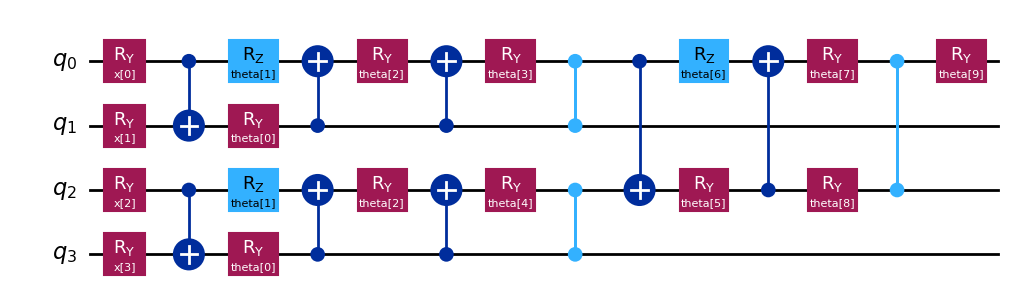

In [6]:
def build_qcnn_style_circuit(n_qubits=4):
    """Build a compact QCNN-style classifier circuit."""
    if n_qubits != 4:
        raise ValueError("This demo circuit is written for exactly four qubits.")

    x = ParameterVector("x", n_qubits)
    theta = ParameterVector("theta", 10)
    qc = QuantumCircuit(n_qubits)

    # Feature encoding: one compact visual/radiomics feature per qubit.
    for q in range(n_qubits):
        qc.ry(x[q], q)

    # Local convolution-like block on pair (0, 1).
    qc.cx(0, 1)
    qc.ry(theta[0], 1)
    qc.rz(theta[1], 0)
    qc.cx(1, 0)
    qc.ry(theta[2], 0)

    # Shared local convolution-like block on pair (2, 3).
    qc.cx(2, 3)
    qc.ry(theta[0], 3)
    qc.rz(theta[1], 2)
    qc.cx(3, 2)
    qc.ry(theta[2], 2)

    # Pooling-like interactions: concentrate pair information into qubits 0 and 2.
    qc.cx(1, 0)
    qc.ry(theta[3], 0)
    qc.cz(1, 0)
    qc.cx(3, 2)
    qc.ry(theta[4], 2)
    qc.cz(3, 2)

    # Final interaction and readout preparation.
    qc.cx(0, 2)
    qc.ry(theta[5], 2)
    qc.rz(theta[6], 0)
    qc.cx(2, 0)
    qc.ry(theta[7], 0)
    qc.ry(theta[8], 2)
    qc.cz(0, 2)
    qc.ry(theta[9], 0)

    return qc, list(x), list(theta)


def readout_q0(measured_integer):
    """Class label is the measured value of qubit 0."""
    return measured_integer & 1

qcnn_circuit, input_params, weight_params = build_qcnn_style_circuit()
print("qubits:", qcnn_circuit.num_qubits)
print("trainable weights:", len(weight_params))
print("circuit depth:", qcnn_circuit.depth())
qcnn_circuit.draw(output="mpl")

## 8. Evaluation Helpers

For the rare-event run, the QNN fitting subset includes every available anomaly plus a controlled number of normal samples. That makes it behave more like a screening model.

The QCNN also gets a simple calibration step in the imbalanced setting: choose a probability threshold on the calibration split to target high recall. This uses training-side data only, not the held-out test labels.


In [7]:
def metric_row(dataset_name, model_name, y_true, y_pred, scores=None):
    row = {
        "dataset": dataset_name,
        "model": model_name,
        "ordinary_accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "anomaly_f1": f1_score(y_true, y_pred, zero_division=0),
        "anomaly_recall": ((y_pred == 1) & (y_true == 1)).sum() / max(1, (y_true == 1).sum()),
        "false_alarm_rate": ((y_pred == 1) & (y_true == 0)).sum() / max(1, (y_true == 0).sum()),
    }
    if scores is not None:
        row["average_precision"] = average_precision_score(y_true, scores)
        row["roc_auc"] = roc_auc_score(y_true, scores)
    else:
        row["average_precision"] = np.nan
        row["roc_auc"] = np.nan
    return row


def print_row(row):
    print(
        f"{row['dataset']:<23s} {row['model']:<28s} "
        f"acc={row['ordinary_accuracy']:.3f} "
        f"bal={row['balanced_accuracy']:.3f} "
        f"recall={row['anomaly_recall']:.3f} "
        f"false_alarm={row['false_alarm_rate']:.3f} "
        f"F1={row['anomaly_f1']:.3f} "
        f"AP={row['average_precision']:.3f}"
    )



def choose_threshold_for_target_recall(y_true, scores, target_recall=0.85):
    """Choose a screening threshold using only calibration data.

    Lower thresholds catch more anomalies but create more false alarms.
    Among thresholds that hit the target recall, choose the one with the
    lowest false-alarm rate.
    """
    if (y_true == 1).sum() == 0:
        return 0.5

    candidates = np.unique(np.r_[0.0, 0.5, 1.0, scores])
    feasible = []
    fallback = []
    for threshold in candidates:
        pred = (scores >= threshold).astype(int)
        recall = ((pred == 1) & (y_true == 1)).sum() / max(1, (y_true == 1).sum())
        false_alarm = ((pred == 1) & (y_true == 0)).sum() / max(1, (y_true == 0).sum())
        record = (false_alarm, -threshold, recall, threshold)
        if recall >= target_recall:
            feasible.append(record)
        fallback.append((-recall, false_alarm, -threshold, threshold))

    if feasible:
        return min(feasible)[-1]
    return min(fallback)[-1]

def qnn_fit_subset(X_fit, y_fit, dataset_name, seed=SEED):
    rng = np.random.default_rng(seed)
    anomaly_idx = np.flatnonzero(y_fit == 1)
    normal_idx = np.flatnonzero(y_fit == 0)

    if y_fit.mean() < 0.20:
        # Rare-event regime: every anomaly plus three times as many normal samples.
        n_normal = min(len(normal_idx), len(anomaly_idx) * 3)
        chosen = anomaly_idx.tolist() + rng.choice(normal_idx, size=n_normal, replace=False).tolist()
    else:
        # Balanced regime: balanced subset for stable QNN fitting.
        n_each = min(len(anomaly_idx), len(normal_idx), 36)
        chosen = rng.choice(anomaly_idx, size=n_each, replace=False).tolist()
        chosen += rng.choice(normal_idx, size=n_each, replace=False).tolist()

    rng.shuffle(chosen)
    print(dataset_name, "QNN fit subset clean/anomaly:", int((y_fit[chosen] == 0).sum()), int((y_fit[chosen] == 1).sum()))
    return X_fit[chosen], y_fit[chosen]

## 9. Run Both Experiments

For each dataset we compare:

- all-normal baseline,
- class-weighted RBF SVM,
- class-weighted random forest,
- QCNN-style QNN.


In [8]:
rows = []
predictions = {}

for dataset_name, (X_data, y_data, scores_data, threshold, images, Z_hidden) in datasets.items():
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_data,
        y_data,
        test_size=0.35,
        random_state=SEED,
        stratify=y_data,
    )
    X_fit, X_cal, y_fit, y_cal = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.25,
        random_state=SEED,
        stratify=y_train_full,
    )

    print()
    print(dataset_name)
    print("fit/test clean/anomaly:", int((y_fit == 0).sum()), int((y_fit == 1).sum()), "/", int((y_test == 0).sum()), int((y_test == 1).sum()))

    # Baseline: predict no anomalies.
    all_normal = np.zeros_like(y_test)
    row = metric_row(dataset_name, "All-normal baseline", y_test, all_normal)
    rows.append(row)
    print_row(row)

    # Classical baselines.
    classical_models = {
        "RBF SVM, class-weighted": Pipeline([
            ("scale", StandardScaler()),
            ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=SEED)),
        ]),
        "Random Forest, weighted": RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=SEED,
        ),
    }

    for model_name, model in classical_models.items():
        model.fit(X_fit, y_fit)
        pred = model.predict(X_test)
        model_scores = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
        row = metric_row(dataset_name, model_name, y_test, pred, scores=model_scores)
        rows.append(row)
        print_row(row)

    # QCNN-style QNN.
    X_qnn_fit, y_qnn_fit = qnn_fit_subset(X_fit, y_fit, dataset_name)
    sampler_qnn = SamplerQNN(
        circuit=qcnn_circuit,
        sampler=StatevectorSampler(seed=SEED),
        input_params=input_params,
        weight_params=weight_params,
        interpret=readout_q0,
        output_shape=2,
    )
    rng = np.random.default_rng(SEED)
    qcnn_classifier = NeuralNetworkClassifier(
        neural_network=sampler_qnn,
        optimizer=COBYLA(maxiter=50),
        initial_point=rng.uniform(-0.2, 0.2, size=len(weight_params)),
    )
    qcnn_classifier.fit(X_qnn_fit, y_qnn_fit)
    qcnn_scores = qcnn_classifier.predict_proba(X_test)[:, 1]

    if y_fit.mean() < 0.20:
        qcnn_cal_scores = qcnn_classifier.predict_proba(X_cal)[:, 1]
        qcnn_threshold = choose_threshold_for_target_recall(y_cal, qcnn_cal_scores, target_recall=0.85)
        qcnn_pred = (qcnn_scores >= qcnn_threshold).astype(int)
        print("QCNN screening threshold from calibration:", round(float(qcnn_threshold), 3))
    else:
        qcnn_threshold = 0.5
        qcnn_pred = qcnn_classifier.predict(X_test)

    row = metric_row(dataset_name, "QCNN-style QNN", y_test, qcnn_pred, scores=qcnn_scores)
    rows.append(row)
    print_row(row)

    predictions[dataset_name] = {
        "y_test": y_test,
        "all_normal": all_normal,
        "qcnn_pred": qcnn_pred,
        "qcnn_scores": qcnn_scores,
        "qcnn_threshold": qcnn_threshold,
    }

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.



Balanced benchmark
fit/test clean/anomaly: 63 63 / 46 45
Balanced benchmark      All-normal baseline          acc=0.505 bal=0.500 recall=0.000 false_alarm=0.000 F1=0.000 AP=nan
Balanced benchmark      RBF SVM, class-weighted      acc=0.725 bal=0.725 recall=0.689 false_alarm=0.239 F1=0.713 AP=0.747
Balanced benchmark      Random Forest, weighted      acc=0.681 bal=0.682 recall=0.733 false_alarm=0.370 F1=0.695 AP=0.773
Balanced benchmark QNN fit subset clean/anomaly: 36 36


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Balanced benchmark      QCNN-style QNN               acc=0.681 bal=0.681 recall=0.622 false_alarm=0.261 F1=0.659 AP=0.710

Imbalanced deployment
fit/test clean/anomaly: 116 10 / 84 7
Imbalanced deployment   All-normal baseline          acc=0.923 bal=0.500 recall=0.000 false_alarm=0.000 F1=0.000 AP=nan
Imbalanced deployment   RBF SVM, class-weighted      acc=0.813 bal=0.571 recall=0.286 false_alarm=0.143 F1=0.190 AP=0.054
Imbalanced deployment   Random Forest, weighted      acc=0.923 bal=0.500 recall=0.000 false_alarm=0.000 F1=0.000 AP=0.123
Imbalanced deployment QNN fit subset clean/anomaly: 30 10
QCNN screening threshold from calibration: 0.089
Imbalanced deployment   QCNN-style QNN               acc=0.099 bal=0.512 recall=1.000 false_alarm=0.976 F1=0.146 AP=0.302


## 10. Metric Table

These are the numbers to pull into speaker notes. Balanced accuracy and anomaly recall matter more than ordinary accuracy here.


In [9]:
print("Final metric table")
print("-" * 132)
print(f"{'dataset':<23s} {'model':<28s} {'acc':>7s} {'bal_acc':>8s} {'recall':>8s} {'false_alarm':>12s} {'F1':>7s} {'AP':>7s}")
for row in rows:
    print(
        f"{row['dataset']:<23s} "
        f"{row['model']:<28s} "
        f"{row['ordinary_accuracy']:7.3f} "
        f"{row['balanced_accuracy']:8.3f} "
        f"{row['anomaly_recall']:8.3f} "
        f"{row['false_alarm_rate']:12.3f} "
        f"{row['anomaly_f1']:7.3f} "
        f"{row['average_precision']:7.3f}"
    )

Final metric table
------------------------------------------------------------------------------------------------------------------------------------
dataset                 model                            acc  bal_acc   recall  false_alarm      F1      AP
Balanced benchmark      All-normal baseline            0.505    0.500    0.000        0.000   0.000     nan
Balanced benchmark      RBF SVM, class-weighted        0.725    0.725    0.689        0.239   0.713   0.747
Balanced benchmark      Random Forest, weighted        0.681    0.682    0.733        0.370   0.695   0.773
Balanced benchmark      QCNN-style QNN                 0.681    0.681    0.622        0.261   0.659   0.710
Imbalanced deployment   All-normal baseline            0.923    0.500    0.000        0.000   0.000     nan
Imbalanced deployment   RBF SVM, class-weighted        0.813    0.571    0.286        0.143   0.190   0.054
Imbalanced deployment   Random Forest, weighted        0.923    0.500    0.000        0.000 

## 11. Why Recall Matters More Than Accuracy Here

In the imbalanced setting, the QCNN is used like a screener. It is allowed to flag extra normal samples if that helps catch more anomalies.

That is why we report false-alarm rate beside recall. A high-recall model with too many false alarms is not a final diagnosis system; it is a possible first-pass triage step.


In [10]:
def prediction_diagnostic(dataset_name, pred_data):
    y_true = pred_data["y_test"]
    pred = pred_data["qcnn_pred"]
    scores = pred_data["qcnn_scores"]

    tn = int(((pred == 0) & (y_true == 0)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    tp = int(((pred == 1) & (y_true == 1)).sum())

    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)

    print(dataset_name)
    print("  true normal/anomaly     :", int((y_true == 0).sum()), int((y_true == 1).sum()))
    print("  predicted normal/anomaly:", int((pred == 0).sum()), int((pred == 1).sum()))
    print("  TN FP FN TP             :", tn, fp, fn, tp)
    print("  anomaly precision       :", round(precision, 3))
    print("  anomaly recall          :", round(recall, 3))
    print("  mean score, true normal :", round(float(scores[y_true == 0].mean()), 3))
    print("  mean score, true anomaly:", round(float(scores[y_true == 1].mean()), 3))
    print()

for dataset_name, pred_data in predictions.items():
    prediction_diagnostic(dataset_name, pred_data)

Balanced benchmark
  true normal/anomaly     : 46 45
  predicted normal/anomaly: 51 40
  TN FP FN TP             : 34 12 17 28
  anomaly precision       : 0.7
  anomaly recall          : 0.622
  mean score, true normal : 0.388
  mean score, true anomaly: 0.562

Imbalanced deployment
  true normal/anomaly     : 84 7
  predicted normal/anomaly: 2 89
  TN FP FN TP             : 2 82 0 7
  anomaly precision       : 0.079
  anomaly recall          : 1.0
  mean score, true normal : 0.505
  mean score, true anomaly: 0.569



## 12. Leakage Check

The models receive only `X`, the four features compressed from each 8x8 image patch.

The hidden synthetic variables, hidden score, and threshold are used to build the toy benchmark and make explanatory plots. They are **not** passed into the SVM, random forest, or QCNN training/prediction calls. Test labels are used only after prediction to compute metrics.

Still, this is a synthetic benchmark. A real claim would need real held-out image data, a feature extractor fitted only on training data, and stronger classical baselines.


## 13. Balanced vs Imbalanced Results

The useful message is modest:

- on the balanced benchmark, the classical baselines are strong,
- on the imbalanced deployment setting, ordinary accuracy becomes misleading,
- the QCNN behaves like a high-recall screener rather than a perfect classifier.


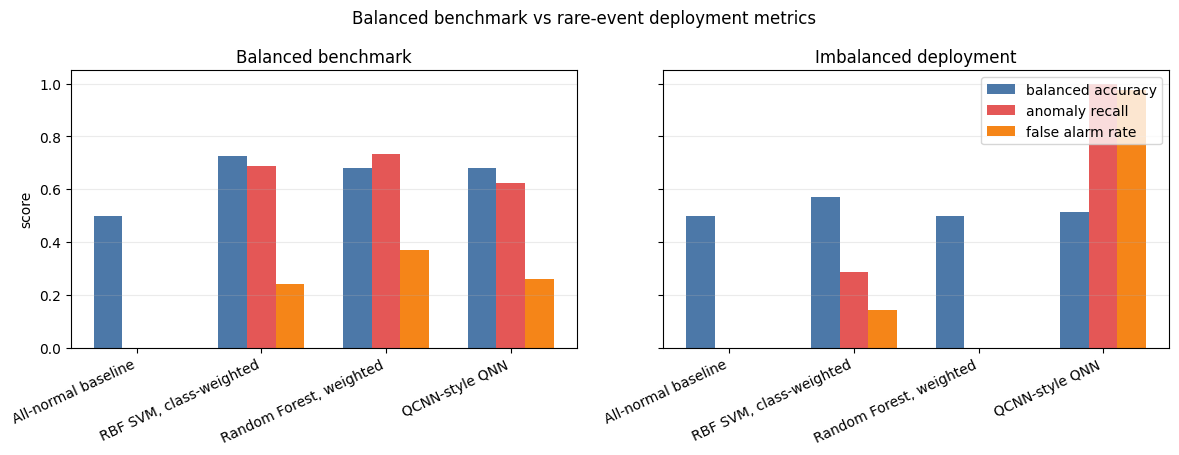

In [11]:
plot_models = ["All-normal baseline", "RBF SVM, class-weighted", "Random Forest, weighted", "QCNN-style QNN"]
plot_metrics = ["balanced_accuracy", "anomaly_recall", "false_alarm_rate"]
metric_labels = ["balanced accuracy", "anomaly recall", "false alarm rate"]
colors = ["#4C78A8", "#E45756", "#F58518"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, dataset_name in zip(axes, datasets.keys()):
    subset = [row for row in rows if row["dataset"] == dataset_name]
    x_axis = np.arange(len(plot_models))
    width = 0.23
    for offset, metric, label, color in zip([-width, 0, width], plot_metrics, metric_labels, colors):
        vals = [next(row for row in subset if row["model"] == model)[metric] for model in plot_models]
        ax.bar(x_axis + offset, vals, width, label=label, color=color)
    ax.set_title(dataset_name)
    ax.set_xticks(x_axis)
    ax.set_xticklabels(plot_models, rotation=25, ha="right")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("score")
axes[1].legend(loc="upper right")
fig.suptitle("Balanced benchmark vs rare-event deployment metrics")
fig.tight_layout()
plt.show()

## 14. Confusion Matrices for Imbalanced Deployment

This is probably the clearest plot for the presentation: the all-normal baseline looks accurate but misses every anomaly; the calibrated QCNN catches more of the anomaly class, but it also creates false alarms.


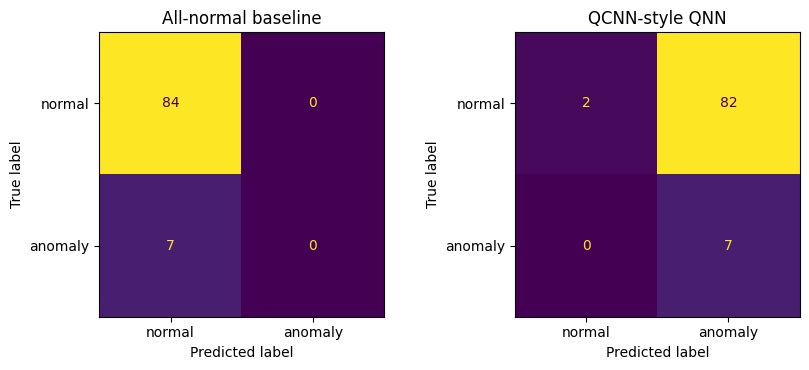

In [12]:
imb = predictions["Imbalanced deployment"]
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.8))

ConfusionMatrixDisplay.from_predictions(
    imb["y_test"],
    imb["all_normal"],
    display_labels=["normal", "anomaly"],
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("All-normal baseline")

ConfusionMatrixDisplay.from_predictions(
    imb["y_test"],
    imb["qcnn_pred"],
    display_labels=["normal", "anomaly"],
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("QCNN-style QNN")

fig.tight_layout()
plt.show()

## 15. QCNN Precision-Recall Curves

Precision-recall is more useful than accuracy when anomalies are rare.


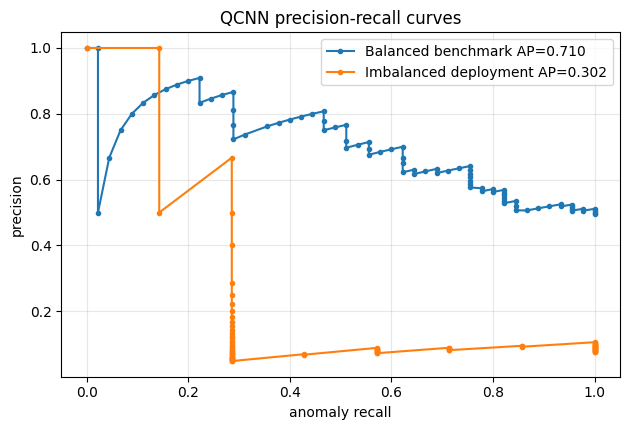

In [13]:
plt.figure(figsize=(6.4, 4.4))
for dataset_name, pred_data in predictions.items():
    precision, recall, _ = precision_recall_curve(pred_data["y_test"], pred_data["qcnn_scores"])
    ap = average_precision_score(pred_data["y_test"], pred_data["qcnn_scores"])
    plt.plot(recall, precision, marker=".", label=f"{dataset_name} AP={ap:.3f}")
plt.xlabel("anomaly recall")
plt.ylabel("precision")
plt.title("QCNN precision-recall curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 16. Takeaways

What we would say out loud:

> We tested a QCNN-style quantum classifier on compressed image features in two settings. The balanced benchmark is useful for comparison, but the rare-event setting is closer to the motivating use case. In that setting, accuracy alone is misleading: predicting everything normal looks good but misses every anomaly. With a calibration threshold, the QCNN behaves as a screening model, trading false alarms for better anomaly capture.

Where this could fit:

- industrial: micro-cracks, wafer defects, battery electrode defects, weld anomalies,
- medical: rare lesion screening, abnormal tissue texture, low-prevalence pathology triage.

Limitations we should be clear about:

- synthetic data,
- simple hand-built compression,
- simulated QCNN, not hardware,
- no proven quantum advantage,
- needs real datasets and stronger classical comparisons.

Honest final claim:

> Structured QNNs may be useful as compact screeners for rare visual anomalies when labels are scarce and the signal depends on coupled image features.


## References and AI Tools Disclosure

This notebook was drafted and revised with OpenAI Codex/GPT-5 assistance in the local hackathon workspace. The team reviewed the framing and should verify all claims before presenting results.

AI-assisted notebooks in this `main_challenge` folder:

- `01_defect_classical_hardness_audit.ipynb`
- `02_quantum_kernel_teacher_defects.ipynb`
- `03_projected_quantum_kernel_features.ipynb`
- `04_qnn_vs_kernel_bakeoff.ipynb`
- `05_qcnn_industrial_microdefects.ipynb`
- `06_data_reuploading_qnn_microdefects.ipynb`
- `07_qnn_kernel_pivot_scoreboard.ipynb`
- `08_imbalanced_rare_defect_qnn.ipynb`
- `09_normal_only_anomaly_detection.ipynb`
- `10_heat_exchanger_network_qubo_qaoa.ipynb`
- `11_Final_QCNN_rare_defect_detection.ipynb`

References used for the quantum-ML and optimization direction:

- Cong, Choi, and Lukin, "Quantum convolutional neural networks," Nature Physics 15, 1273-1278 (2019): https://www.nature.com/articles/s41567-019-0648-8
- Perez-Salinas et al., "Data re-uploading for a universal quantum classifier," Quantum 4, 226 (2020): https://doi.org/10.22331/q-2020-02-06-226 and https://arxiv.org/abs/1907.02085
- McClean et al., "Barren plateaus in quantum neural network training landscapes," Nature Communications 9, 4812 (2018): https://www.nature.com/articles/s41467-018-07090-4
- Havlicek et al., "Supervised learning with quantum-enhanced feature spaces," Nature 567, 209-212 (2019): https://www.nature.com/articles/s41586-019-0980-2
- Scholkopf et al., "Estimating the Support of a High-Dimensional Distribution," Neural Computation 13(7), 1443-1471 (2001): https://doi.org/10.1162/089976601750264965
- Qiskit Machine Learning `SamplerQNN` documentation: https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.neural_networks.SamplerQNN.html
